In [1]:
import numpy as np
import matplotlib.pyplot as plt

import clmm

cosmo = clmm.Cosmology(
    H0=70.0,
    Omega_dm0=0.3 - 0.045,
    Omega_b0=0.045,
    Omega_k0=0.0,
)

In [2]:
# Redshift grid where we evaluate the lensing kernels.
z_grid = np.linspace(0.001, 2.5, 1500)

# Single-source-plane case:
# 20 individual source galaxies/source planes between z=0.1 and z=2.0.
n_sources = 20
z_sources = np.linspace(0.1, 2.0, n_sources)

print("Source redshifts:")
print(z_sources)

Source redshifts:
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]


In [3]:
def chi_of_z(z):
    """
    Return comoving distance chi(z).

    CLMM's eval_da gives angular diameter distance D_A(z).
    Comoving distance is chi(z) = D_A(z) * (1 + z).
    """
    return cosmo.eval_da(z) * (1.0 + z)


chi_grid = np.array([chi_of_z(z) for z in z_grid])
chi_sources = np.array([chi_of_z(zs) for zs in z_sources])

print("Source comoving distances:")
print(chi_sources)

Source comoving distances:
[ 418.41021955  816.55202238 1194.02673478 1550.91714367 1887.68974584
 2205.09210733 2504.05915936 2785.63559486 3050.91479332 3300.99445281
 3536.94574609 3759.79314935 3970.50295804 4169.97741666 4359.05249836
 4538.49882768 4709.02466107 4871.279067   5025.85536545 5173.29725355]


In [4]:
def single_source_lensing_kernel(chi_lens, chi_source):
    """
    Lensing kernel for a single source plane.

    For matter at comoving distance chi_lens and source at chi_source:

        q(chi) ∝ chi * (chi_source - chi) / chi_source

    for chi_lens < chi_source, and q = 0 otherwise.

    This is the single-galaxy/source-plane version of the lensing kernel.
    """
    q = np.zeros_like(chi_lens)

    mask = chi_lens < chi_source

    q[mask] = (
        chi_lens[mask]
        * (chi_source - chi_lens[mask])
        / chi_source
    )

    return q

In [5]:
# q has shape:
#   number of source galaxies x number of redshift-grid points
#
# Each row is the lensing kernel for one source galaxy/source plane.

q = np.zeros((n_sources, len(z_grid)))

for i, chi_s in enumerate(chi_sources):
    q_i = single_source_lensing_kernel(chi_grid, chi_s)

    # Normalize each original kernel by its own peak for plotting.
    max_q = np.max(q_i)
    if max_q > 0:
        q_i = q_i / max_q

    q[i] = q_i

print("q shape:", q.shape)

q shape: (20, 1500)


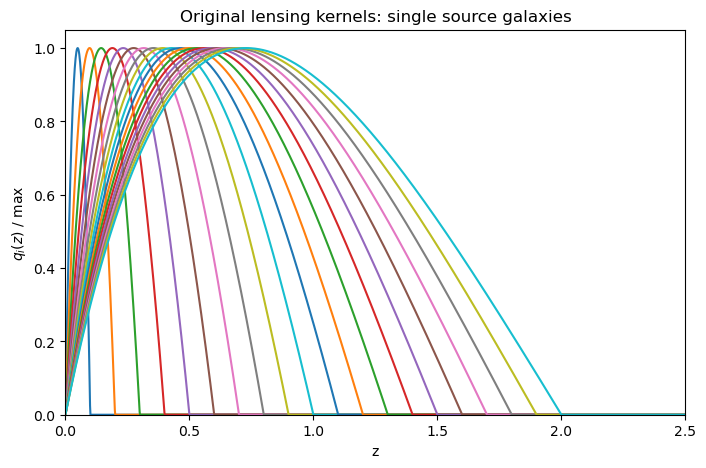

In [6]:
plt.figure(figsize=(8, 5))

for i in range(n_sources):
    plt.plot(z_grid, q[i])

plt.xlabel("z")
plt.ylabel(r"$q_i(z)$ / max")
plt.title("Original lensing kernels: single source galaxies")
plt.xlim(0, 2.5)
plt.ylim(0, 1.05)
plt.show()

In [7]:
def build_bnt_matrix_single_sources(chi_sources):
    """
    Build the BNT matrix for single source planes.

    For the single-source case, the BNT nulling conditions are:

        sum_j M_ij = 0

    and

        sum_j M_ij / chi_j = 0

    using three neighboring source planes:
        i-2, i-1, i

    We set M_ii = 1 and solve for the other two coefficients.
    """

    n = len(chi_sources)
    M = np.zeros((n, n))

    # First source bin is unchanged.
    M[0, 0] = 1.0

    # Second row is a simple difference.
    # True three-source nulling starts at i=2.
    M[1, 0] = -1.0
    M[1, 1] = 1.0

    for i in range(2, n):
        chi_im2 = chi_sources[i - 2]
        chi_im1 = chi_sources[i - 1]
        chi_i = chi_sources[i]

        a = (
            (1.0 / chi_im1 - 1.0 / chi_i)
            / (1.0 / chi_im2 - 1.0 / chi_im1)
        )

        b = -1.0 - a

        M[i, i - 2] = a
        M[i, i - 1] = b
        M[i, i] = 1.0

    return M


M = build_bnt_matrix_single_sources(chi_sources)

print("M shape:", M.shape)
print(M)

M shape: (20, 20)
[[ 1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-1.          1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.3322296  -1.3322296   1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.49778554 -1.49778554  1.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.59687764 -1.59687764  1.          0.
   0.          0

In [8]:
# Apply the BNT transformation.
# Each transformed kernel is a linear combination of original kernels.

q_tilde = M @ q

# Normalize transformed kernels by max absolute value.
# This keeps the sign information.
q_tilde_norm = np.zeros_like(q_tilde)

for i in range(n_sources):
    max_abs = np.max(np.abs(q_tilde[i]))
    if max_abs > 0:
        q_tilde_norm[i] = q_tilde[i] / max_abs

print("q_tilde shape:", q_tilde.shape)

q_tilde shape: (20, 1500)


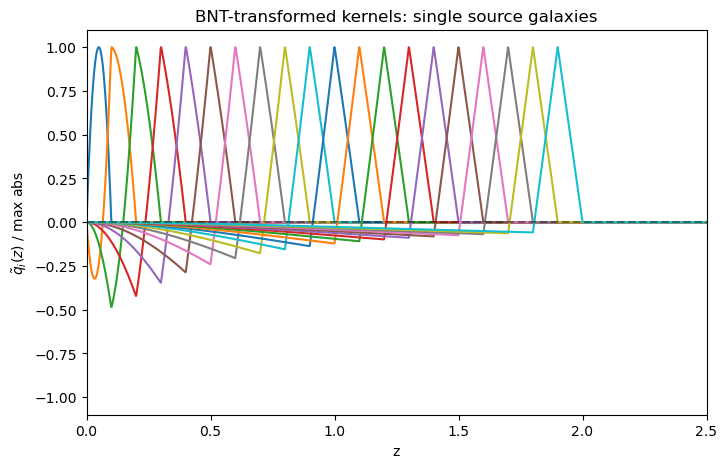

In [9]:
plt.figure(figsize=(8, 5))

for i in range(n_sources):
    plt.plot(z_grid, q_tilde_norm[i])

plt.xlabel("z")
plt.ylabel(r"$\tilde{q}_i(z)$ / max abs")
plt.title("BNT-transformed kernels: single source galaxies")
plt.xlim(0, 2.5)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color="k", linestyle="--", alpha=0.4)
plt.show()

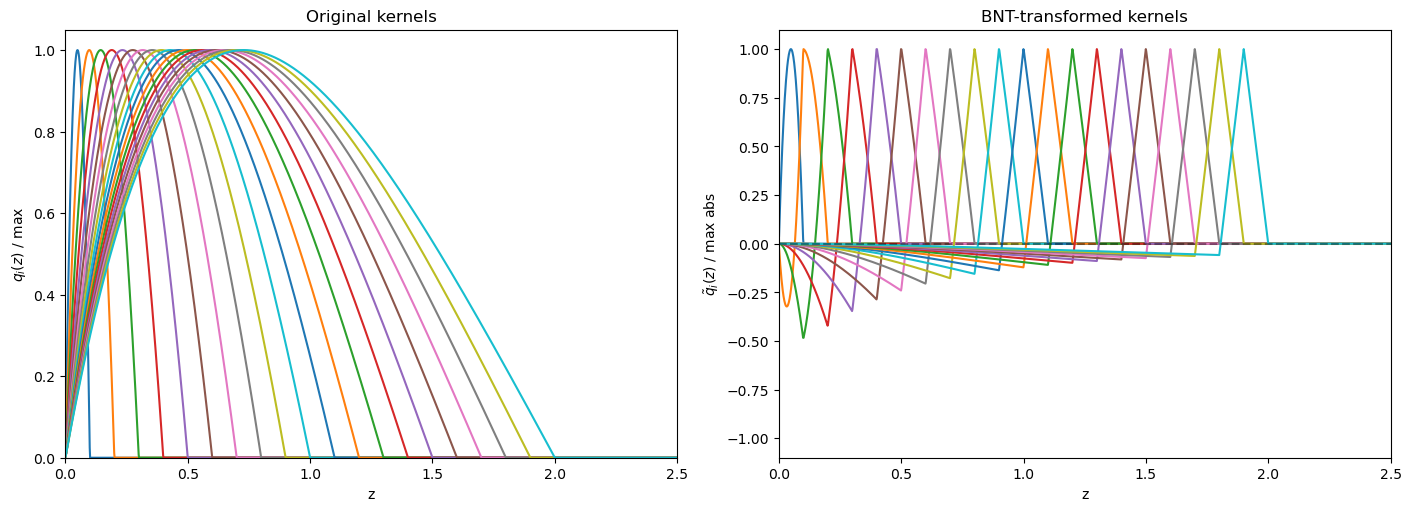

In [10]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 5), layout="constrained")

for i in range(n_sources):
    axs[0].plot(z_grid, q[i])

axs[0].set_title("Original kernels")
axs[0].set_xlabel("z")
axs[0].set_ylabel(r"$q_i(z)$ / max")
axs[0].set_xlim(0, 2.5)
axs[0].set_ylim(0, 1.05)

for i in range(n_sources):
    axs[1].plot(z_grid, q_tilde_norm[i])

axs[1].set_title("BNT-transformed kernels")
axs[1].set_xlabel("z")
axs[1].set_ylabel(r"$\tilde{q}_i(z)$ / max abs")
axs[1].set_xlim(0, 2.5)
axs[1].set_ylim(-1.1, 1.1)
axs[1].axhline(0, color="k", linestyle="--", alpha=0.4)

plt.show()